# 2.1. Área bajo restauración

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Datos CBD

In [2]:
data_cbd = pd.read_excel("data/scbd-ort-GBF-INDICATOR-2.2-data.xlsx", header=0, sheet_name="BD_restoration_ecology")
data_cbd

,ID,Restoration approach,Restoration program,Restoration action,Institution,Year,Region,ha,Footnote,Source_link
0,RE-1,Restoration ecology,(+bosques),(+bosques),CONAF-FAO,2025,Maule,2319.00,NaN,https://docs.google.com/document/d/18C83Qd9Ibl...
1,RE-2,Restoration ecology,(+bosques),(+bosques),CONAF-FAO,2025,Ñuble,1247.00,NaN,https://docs.google.com/document/d/18C83Qd9Ibl...
2,RE-3,Restoration ecology,(+bosques),(+bosques),CONAF-FAO,2025,Biobío,2608.00,NaN,https://docs.google.com/document/d/18C83Qd9Ibl...
3,RE-4,Restoration ecology,(+bosques),(+bosques),CONAF-FAO,2025,La Araucanía,2081.00,NaN,https://docs.google.com/document/d/18C83Qd9Ibl...
4,RE-5,Restoration ecology,(+bosques),(+bosques),CONAF-FAO,2025,Los Ríos,3574.00,NaN,https://docs.google.com/document/d/18C83Qd9Ibl...
...,...,...,...,...,...,...,...,...,...,...
128,RE-129,Restoration ecology,Other private restoration action,Programa de Restauracion Hidrológica y Foresta...,REGISTRO INICIATIVAS RESTAURACION 2024,Sin información precisa,Coquimbo,314.00,NaN,GEF restauración de paisajes
129,RE-130,Restoration ecology,Other private restoration action,Restauración de microcuencas con presencia de ...,REGISTRO INICIATIVAS RESTAURACION 2024,Sin información precisa,Coquimbo,21.90,NaN,GEF restauración de paisajes
130,RE-131,Restoration ecology,Other private restoration action,Restauración de microcuencas con presencia de ...,REGISTRO INICIATIVAS RESTAURACION 2024,Sin información precisa,Coquimbo,326.70,NaN,GEF restauración de paisajes
131,RE-132,Restoration ecology,SIRSD,SIRSD SAG,SAG,2022,Ñuble,3255.90,Reporte de cofinanciamiento por parte de SIRSD...,GEF restauración de paisajes


In [3]:
# Replace not standard names
data_cbd["Region"] = data_cbd["Region"].replace({
    "Valparaiso": "Valparaíso",
    "Los ríos": "Los Ríos",
    "Los lagos": "Los Lagos",
    "Araucanía": "La Araucanía",
    "Múltiples regiones": "Interregional"
})

In [4]:
data_region_cbd = data_cbd.groupby('Region')['ha'].sum().reset_index()
data_region_cbd

,Region,ha
0,Antofagasta,261.000
1,Arica y Parinacota,3068.000
2,Atacama,158.000
3,Aysén,19168.000
4,Biobío,4205.504
5,Coquimbo,3100.530
6,Interregional,62974.000
7,La Araucanía,5563.800
8,Los Lagos,5979.020
9,Los Ríos,8809.000


In [5]:
print(f"Hectáreas totales {data_region_cbd['ha'].sum():.2f} ha")

Hectáreas totales 138270.81 ha


In [6]:
list(data_region_cbd["Region"])

['Antofagasta',
 'Arica y Parinacota',
 'Atacama',
 'Aysén',
 'Biobío',
 'Coquimbo',
 'Interregional',
 'La Araucanía',
 'Los Lagos',
 'Los Ríos',
 'Magallanes',
 'Maule',
 'Metropolitana',
 "O'Higgins",
 'Tarapacá',
 'Valparaíso',
 'Ñuble']

In [7]:
region_order = [
    'Arica y Parinacota',
    'Tarapacá',
    'Antofagasta',
    'Atacama',
    'Coquimbo',
    'Valparaíso',
    'Metropolitana',
    "O'Higgins",
    'Maule',
    'Ñuble',
    'Biobío',
    'La Araucanía',
    'Los Ríos',
    'Los Lagos',
    'Aysén',
    'Magallanes',
    'Interregional',
]

In [8]:
data_region_cbd["Region"] = pd.Categorical(data_region_cbd["Region"],
                                           categories=region_order,
                                           ordered=True)
data_region_cbd.sort_values("Region", inplace=True)
data_region_cbd

,Region,ha
1,Arica y Parinacota,3068.000
14,Tarapacá,306.000
0,Antofagasta,261.000
2,Atacama,158.000
5,Coquimbo,3100.530
15,Valparaíso,2462.400
12,Metropolitana,692.226
13,O'Higgins,8162.640
11,Maule,6295.590
16,Ñuble,6006.100


In [9]:
region_count = len(data_region_cbd)
sorted_region_ha = data_region_cbd.sort_values("ha")
first_cut = sorted_region_ha.iloc[region_count - 2]["ha"]
second_cut = sorted_region_ha.iloc[region_count - 1]["ha"]
sorted_region_ha

,Region,ha
2,Atacama,158.000
0,Antofagasta,261.000
14,Tarapacá,306.000
12,Metropolitana,692.226
10,Magallanes,1059.000
15,Valparaíso,2462.400
1,Arica y Parinacota,3068.000
5,Coquimbo,3100.530
4,Biobío,4205.504
7,La Araucanía,5563.800


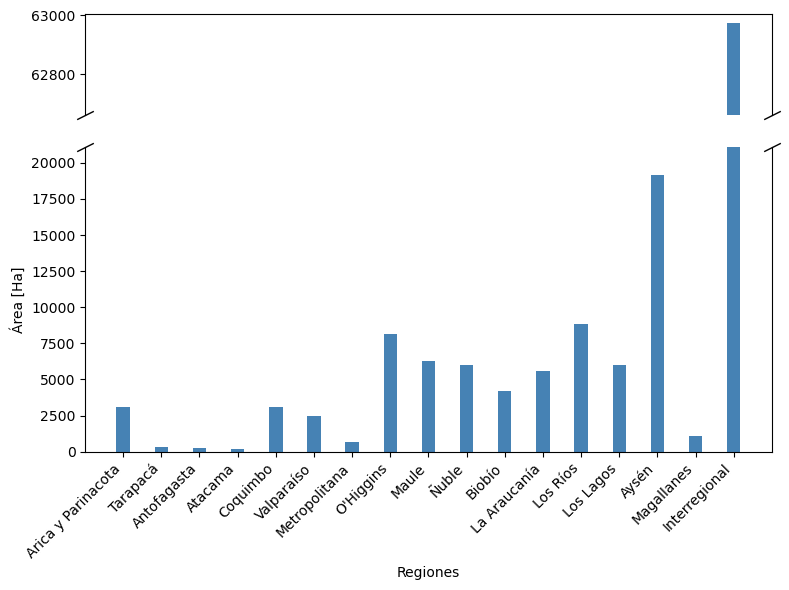

In [10]:
fig, (ax, ax2) = plt.subplots(2, 1, sharex=True, height_ratios=[1, 3], figsize=(8, 6))

position = np.arange(len(data_region_cbd))
width = 0.35

ax.bar(position, data_region_cbd["ha"], width, label="Área [Ha]", color="steelblue")
ax2.bar(position, data_region_cbd["ha"], width, label="Área [Ha]", color="steelblue")

ax.set_ylim(second_cut * (1 - 5e-3), second_cut * (1 + 5e-4))
ax2.set_ylim(0, first_cut * 1.1)

fig.subplots_adjust(hspace=0.05)

# hide the spines between ax and ax2
ax.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax.xaxis.tick_top()
ax.xaxis.set_visible(False)
ax.tick_params(labeltop=False)
ax2.xaxis.tick_bottom()

d = .5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax.plot([0, 1], [0, 0], transform=ax.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

ax2.set_xlabel("Regiones")
ax2.set_ylabel("Área [Ha]")

ax2.set_xticks(position)
ax2.set_xticklabels(data_region_cbd["Region"], rotation=45, ha='right')

fig.tight_layout()
fig.savefig("regiones_cbd.png")
plt.show()
plt.close(fig)

In [11]:
data_time_cbd = data_cbd.groupby('Year')['ha'].sum().reset_index()
data_time_cbd['ha (cumulative)'] = data_time_cbd['ha'].cumsum()
# data_time_cbd = data_time_cbd.drop(4)
# data_time_cbd["Year"] = data_time_cbd["Year"].astype(int)
data_time_cbd

,Year,ha,ha (cumulative)
0,2022,14537.90,14537.90
1,2023,16237.00,30774.90
2,2024,10640.00,41414.90
3,2025,25622.98,67037.88
4,Sin información precisa,71232.93,138270.81


Debido a presencia de datos sin año (`Sin información precisa`), se omite el gráfico de tiempo para datos CBD.

```python
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(data_time_cbd["Year"], data_time_cbd["ha (cumulative)"], marker='o', color="steelblue", label="Área acumulada")
ax.text(2025 - 0.34, data_time_cbd["ha (cumulative)"][3], f'{data_time_cbd["ha (cumulative)"][3]} ha')
ax.set_xlabel("Año")
ax.set_ylabel("Área [Ha]")

ax.set_xticks(data_time_cbd["Year"])
ax.set_xticklabels(data_time_cbd["Year"], rotation=45, ha='right')
ax.set_ylim(0)

# ax2 = ax.twinx()
ax.plot(data_time_cbd["Year"], data_time_cbd["ha"], marker='o', color="coral", label="Área por año")
ax.legend()

fig.tight_layout()
fig.savefig("years_cbd.png")
plt.show()
plt.close(fig)
```


## Datos Nacionales

In [12]:
data_ch = pd.read_excel("data/scbd-ort-GBF-INDICATOR-2.2-data.xlsx", header=0, sheet_name="BD_Landscape restoration")
data_ch = data_ch.drop(15)
data_ch

,ID,Restoration program,Name,Year,Region,Source,ha
0,L-1,GEF Restauración de paisajes,Reserva de la Biosfera Fray Jorge,2023.0,Coquimbo,PRODOC GEF RESTAURACION,134311
1,L-2,GEF Restauración de paisajes,Corredor Bosques de Casablanca – Peñuelas – Qu...,2023.0,Valparaíso,PRODOC GEF RESTAURACION,75916
2,L-3,GEF Restauración de paisajes,Secano Costero – Nilahue (Región de O’Higgins),2023.0,O´Higgins,PRODOC GEF RESTAURACION,122947
3,L-4,GEF Restauración de paisajes,Curepto – Putú – Huenchullamí – Río Maule (Reg...,2023.0,Maule,PRODOC GEF RESTAURACION,150543
4,L-5,GEF Restauración de paisajes,Secano Interior – Altos de Ninhue (Región de Ñ...,2023.0,Ñuble,PRODOC GEF RESTAURACION,30633
5,L-6,GEF Restauración de paisajes,Cayumanque,2023.0,Ñuble,PRODOC GEF RESTAURACION,126168
6,L-7,GEF Restauración de paisajes,Nahuelbuta – Lanalhue,2023.0,Biobío,PRODOC GEF RESTAURACION,73232
7,L-8,Planes regionales de adaptación al cambio clim...,Medida A1.2.1 Region del Biobio: Reforzamiento...,2025.0,Biobío,NaN,1000
8,L-9,Planes regionales de adaptación al cambio clim...,Medida A1.2.1 Region del Biobio: Absorber CO2 ...,2025.0,Biobío,NaN,1000
9,L-10,Otros instrumentos de planificación a escala d...,Plan de Ordenamiento y Gestión Territorial par...,2018.0,Biobío,https://prela.mma.gob.cl/wp-content/uploads/Re...,36956


In [13]:
# Replace not standard names
data_ch["Region"] = data_ch["Region"].replace({
    "O´Higgins": "O'Higgins",
})

In [14]:
data_region_ch = data_ch.groupby('Region')['ha'].sum().reset_index()
data_region_ch

,Region,ha
0,Biobío,250388
1,Coquimbo,134311
2,Los Lagos,217936
3,Maule,150543
4,Metropolitana,84353
5,O'Higgins,122947
6,Valparaíso,75916
7,Ñuble,156801


In [15]:
print(f"Hectáreas totales {data_region_ch['ha'].sum():.2f} ha")

Hectáreas totales 1193195.00 ha


In [16]:
data_region_ch["Region"] = pd.Categorical(data_region_ch["Region"],
                                          categories=region_order,
                                          ordered=True)
data_region_ch.sort_values("Region", inplace=True)
data_region_ch

,Region,ha
1,Coquimbo,134311
6,Valparaíso,75916
4,Metropolitana,84353
5,O'Higgins,122947
3,Maule,150543
7,Ñuble,156801
0,Biobío,250388
2,Los Lagos,217936


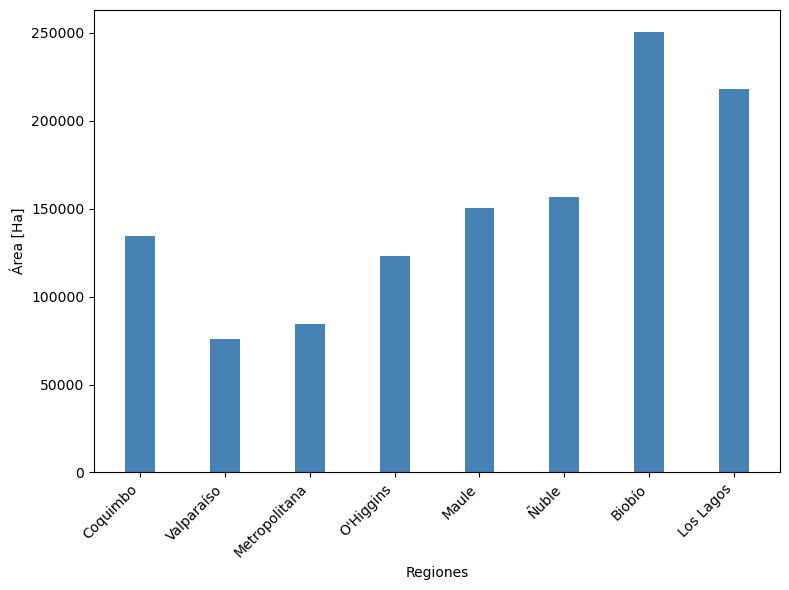

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))

position = np.arange(len(data_region_ch))
width = 0.35

ax.bar(position, data_region_ch["ha"], width, label="Área [Ha]", color="steelblue")
ax.set_xlabel("Regiones")
ax.set_ylabel("Área [Ha]")

ax.set_xticks(position)
ax.set_xticklabels(data_region_ch["Region"], rotation=45, ha='right')

fig.tight_layout()
fig.savefig("regiones_nacional.png")
plt.show()
plt.close(fig)

In [18]:
data_time_ch = data_ch.groupby('Year')['ha'].sum().reset_index()
data_time_ch['ha (cumulative)'] = data_time_ch['ha'].cumsum()
data_time_ch["Year"] = data_time_ch["Year"].astype(int)
data_time_ch

,Year,ha,ha (cumulative)
0,2008,57936,57936
1,2014,84353,142289
2,2017,160000,302289
3,2018,36956,339245
4,2021,26000,365245
5,2023,713750,1078995
6,2024,112200,1191195
7,2025,2000,1193195


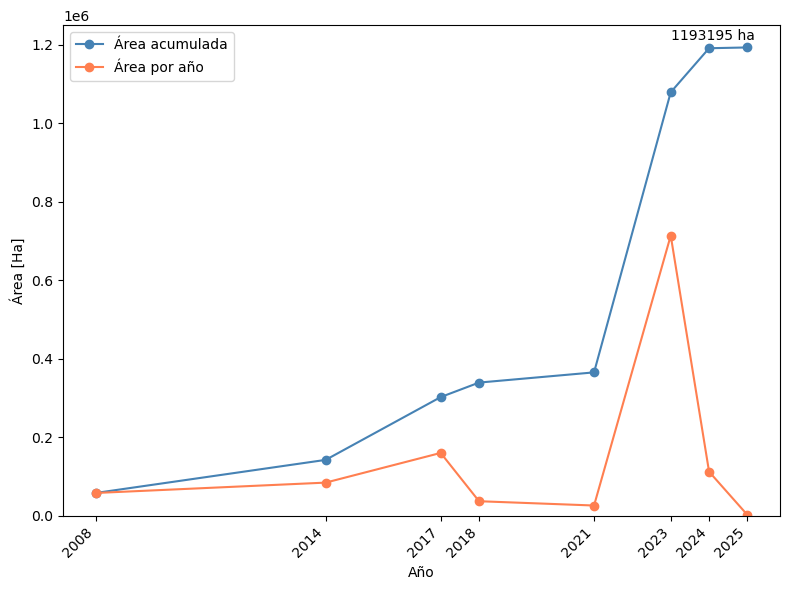

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(data_time_ch["Year"], data_time_ch["ha (cumulative)"], marker='o', color="steelblue", label="Área acumulada")
ax.text(2025 - 2, data_time_ch["ha (cumulative)"][7] + 2e4, f'{data_time_ch["ha (cumulative)"][7]} ha')
ax.set_xlabel("Año")
ax.set_ylabel("Área [Ha]")

ax.set_xticks(data_time_ch["Year"])
ax.set_xticklabels(data_time_ch["Year"], rotation=45, ha='right')
ax.set_ylim(0)

# ax2 = ax.twinx()
ax.plot(data_time_ch["Year"], data_time_ch["ha"], marker='o', color="coral", label="Área por año")
ax.legend()

fig.tight_layout()
fig.savefig("years_nacional.png")
plt.show()
plt.close(fig)